## Training MobileNetV3 model

### With Original Dataset

Found 1437 files belonging to 5 classes.
Using 1150 files for training.
Found 1437 files belonging to 5 classes.
Using 287 files for validation.
Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 343ms/step - accuracy: 0.3492 - loss: 1.8267 - val_accuracy: 0.5366 - val_loss: 1.3472 - learning_rate: 0.0010
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 323ms/step - accuracy: 0.5707 - loss: 1.3254 - val_accuracy: 0.6237 - val_loss: 1.1694 - learning_rate: 0.0010
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 330ms/step - accuracy: 0.5946 - loss: 1.1854 - val_accuracy: 0.6551 - val_loss: 1.0808 - learning_rate: 0.0010
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 350ms/step - accuracy: 0.6308 - loss: 1.1398 - val_accuracy: 0.6028 - val_loss: 1.1351 - learning_rate: 0.0010
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 375ms/step - accuracy: 0.6349 - loss: 1.0362 - val_accuracy: 0.6516 - val_loss: 1.0420 - learning_rate: 0.0010
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 329ms/step - accuracy: 0.6408 - loss: 1.0790 - v

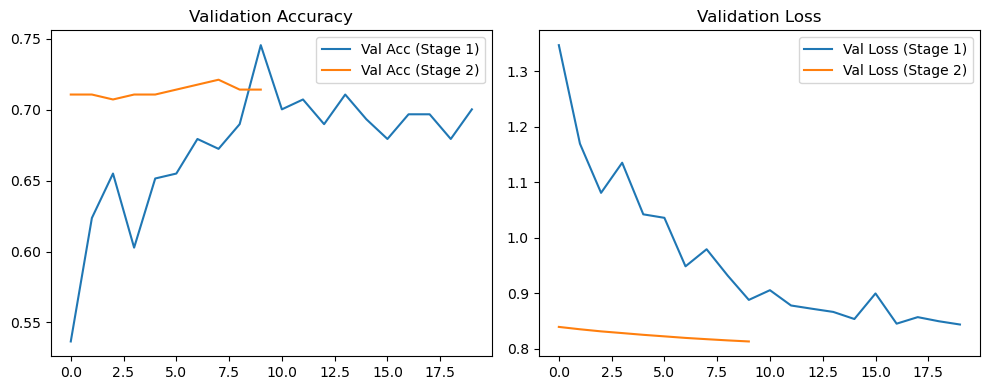

In [47]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import MobileNetV3Small
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import numpy as np
import os

# --- CONFIG ---
dataset_path = "classification_dataset"
save_model_as = "mobilenetv3_original.keras"
img_size = (224, 224)
batch_size = 32
num_classes = 5
epochs_stage1 = 20
epochs_stage2 = 10
seed = 123

# --- DATA LOADING ---
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

# --- CLASS WEIGHTS ---
labels = [label.numpy() for _, label in train_ds.unbatch()]
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)
class_weights = dict(enumerate(class_weights))

# --- DATA AUGMENTATION ---
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(0.1, 0.1)
])

# --- MODEL CONSTRUCTION ---
base_model = MobileNetV3Small(input_shape=img_size + (3,), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze for initial training

model = models.Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# --- CALLBACKS ---
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_model_stage1.keras", save_best_only=True, monitor="val_loss"),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3)
]

# --- TRAIN STAGE 1 (Frozen base) ---
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs_stage1,
    class_weight=class_weights,
    callbacks=callbacks
)

# --- FINE-TUNING ---
#base_model.trainable = True  # Unfreeze the base

# Unfreeze top N layers only (last 30 layers)
fine_tune_at = len(base_model.layers) - 30  

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_ft = [
    tf.keras.callbacks.ModelCheckpoint("best_model_stage2.keras", save_best_only=True, monitor="val_loss"),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3)
]

history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs_stage2,
    class_weight=class_weights,
    callbacks=callbacks_ft
)

# --- SAVE FINAL MODEL ---
model.save(save_model_as)

# --- PLOT ---
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_stage1.history['val_accuracy'], label='Val Acc (Stage 1)')
plt.plot(history_stage2.history['val_accuracy'], label='Val Acc (Stage 2)')
plt.title("Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_stage1.history['val_loss'], label='Val Loss (Stage 1)')
plt.plot(history_stage2.history['val_loss'], label='Val Loss (Stage 2)')
plt.title("Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()


## Further Evaluation

Found 1437 files belonging to 5 classes.
Using 287 files for validation.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

📊 Classification Report: Original Validation Set
              precision    recall  f1-score   support

  commercial       0.99      0.89      0.93        88
    high-end       0.62      0.58      0.60        43
     low-end       0.56      0.74      0.64        70
   mid-range       0.50      0.41      0.45        61
  motorcycle       1.00      1.00      1.00        25

    accuracy                           0.71       287
   macro avg       0.73      0.72      0.73       287
weighted avg       0.73      0.71      0.72       287

✅ Accuracy: 0.7143


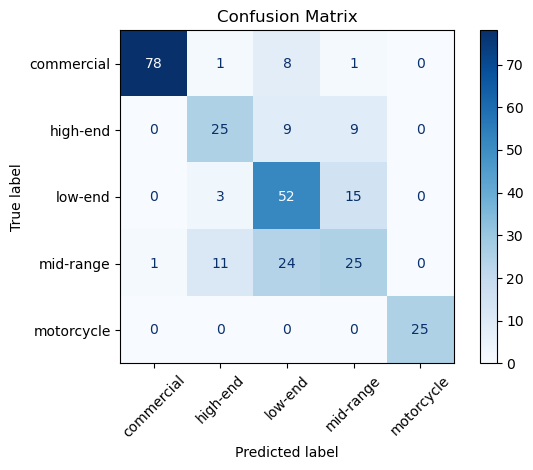

In [49]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load model
model = tf.keras.models.load_model("mobilenetv3_original.keras")

val_ds_original = tf.keras.preprocessing.image_dataset_from_directory(
    "classification_dataset",
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
)

class_names = val_ds_original.class_names

# Helper to evaluate and report
def evaluate_model(ds, label):
    y_true, y_pred = [], []

    for images, labels in ds:
        predictions = model.predict(images)
        y_pred.extend(np.argmax(predictions, axis=1))
        y_true.extend(labels.numpy())

    print(f"\n📊 Classification Report: {label}")
    print(classification_report(y_true, y_pred, target_names=class_names))
    accuracy = np.mean(np.array(y_true) == np.array(y_pred))
    print(f"✅ Accuracy: {accuracy:.4f}")

    # --- CONFUSION MATRIX ---
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

# Evaluate both
evaluate_model(val_ds_original, "Original Validation Set")

## Inference to predict on image

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np

# Load model
model = tf.keras.models.load_model("mobilenetv3_original.keras")

# Class names 
class_names = ['commercial', 'high-end car', 'low-end car', 'mid-range car', 'motorcycle'] 

# Predict function
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Create batch axis

    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions)]

    confidence = 100 * np.max(predictions)

    print(f"Prediction: {predicted_class} ({confidence:.2f}% confidence)")


In [3]:
# usage
predict_image(r"C:\Users\Owner\Documents\MMU\FYP\coding\Screenshot 2025-06-03 015146.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: low-end car (58.70% confidence)
